# DCT Laboratory — Volume II, Chapter 9
## Stochastic Enterprise Optimization
**Seed `26209`** · Companion to the chapter and AXIOM Module **AXIOM-09 (Vol. II)**

Volume I built the randomness; this chapter finally optimizes on it — and the
lab shows uncertainty doing three different things. It **flips a policy**
(Chapter 7's machine with drift risk: gentle stops being optimal at
$p = 0.55$). It **reprices without changing the policy** (log-utility Merton:
$c^* = \rho x$ survives $\sigma$; the value drops by exactly
$\sigma^2/2\rho^2 = 2.0$). And it is **purchasable as a guarantee** (chance
constraints: 95% certainty costs 3.49 extra units). Mirrored in
`DCT_V2_Ch09_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams['figure.dpi']=110

import numpy as np
from scipy.stats import norm
SEED = 26209
BETA = 0.9
# --- Panel 1: the two-state machine, gentle now risky ---
# G: gentle (r=7): stays G w.p. 1-p, drifts to B w.p. p ; hard (r=10): -> B surely
# B: repair (r=-4): -> G ; rundown (r=2): -> B
def gentle_fp(p):
    VG = (7 - 4*BETA*p)/(1 - BETA*(1-p) - BETA**2*p)
    return VG, -4 + BETA*VG
def hard_fp():
    VG = (10 - 4*BETA)/(1 - BETA**2)   # hard -> B surely; repair -> G
    return VG, -4 + BETA*VG
def policy_in_G(p):
    """1 = hard optimal, 0 = gentle optimal (optimal V = max over stationary policies)."""
    return int(hard_fp()[0] > gentle_fp(p)[0])
def p_flip(grid=None):
    grid = grid if grid is not None else [round(0.05*i,2) for i in range(21)]
    for p in grid:
        if policy_in_G(p): return p
    return None
# --- Panel 2: stochastic HJB, log-utility Merton ---
RHO, R, SIG = 0.10, 0.05, 0.20
def A_sig(sig): return (np.log(RHO) + R/RHO - 1 - sig**2/(2*RHO))/RHO
def V_sig(x, sig=SIG): return A_sig(sig) + np.log(x)/RHO
def resid_sig(x, sig=SIG):
    Vp, Vpp = 1/(RHO*x), -1/(RHO*x*x)
    c = RHO*x
    return RHO*V_sig(x,sig) - (np.log(c) + Vp*(R*x - c) + 0.5*sig**2*x*x*Vpp)
# --- Panel 3: chance constraint ---
MU, SM, L = 2.0, 0.5, 10.0
def i_min(conf): return L/(MU - norm.ppf(conf)*SM)

def reference_values():
    VG02, VB02 = gentle_fp(0.2)
    VGh, _ = hard_fp()
    return {
        "VG_p02": round(VG02,4), "VB_p02": round(VB02,4),
        "policy_G_p02": policy_in_G(0.2),
        "VG_hardFP": round(VGh,4),
        "policy_G_p06": policy_in_G(0.6),
        "p_flip": p_flip(),
        "c_star_sigma": round(RHO*10,4),
        "value_drop": round(SIG**2/(2*RHO**2),4),
        "V_sigma_x10": round(V_sig(10.0),4),
        "resid_sigma_x10": round(resid_sig(10.0),4),
        "resid_sigma_x25": round(resid_sig(25.0),4),
        "i_min_95": round(i_min(0.95),4),
        "i_det": round(L/MU,4),
        "guarantee_premium": round(i_min(0.95)-L/MU,4),
        "i_min_99": round(i_min(0.99),4),
    }
if __name__ == "__main__":
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

VG_p02               53.2203
VB_p02               43.8983
policy_G_p02         0
VG_hardFP            33.6842
policy_G_p06         1
p_flip               0.55
c_star_sigma         1.0
value_drop           2.0
V_sigma_x10          -7.0
resid_sigma_x10      0.0
resid_sigma_x25      0.0
i_min_95             8.492
i_det                5.0
guarantee_premium    3.492
i_min_99             11.9499


## Panel 1 — Uncertainty flips a policy
Chapter 7's machine, with gentle operation now risky: it preserves the Good
state only with probability $1-p$. Both candidate policies have closed-form
values; the optimal value is their maximum (Stochastic Enterprise Dynamic
Programming Theorem, expectations inside the Bellman backup). At $p = 0.2$
gentle still wins ($V_G = 53.22$, down from the deterministic 70 — Enterprise
Uncertainty Modifies Optimal Enterprise Policies, Prop.). Sweep $p$: at
**$p = 0.55$ the policy flips to hard** — when care no longer reliably
preserves the asset, harvesting becomes optimal. Volatility is not just a
haircut on value; past a threshold it **rewrites the rule**.

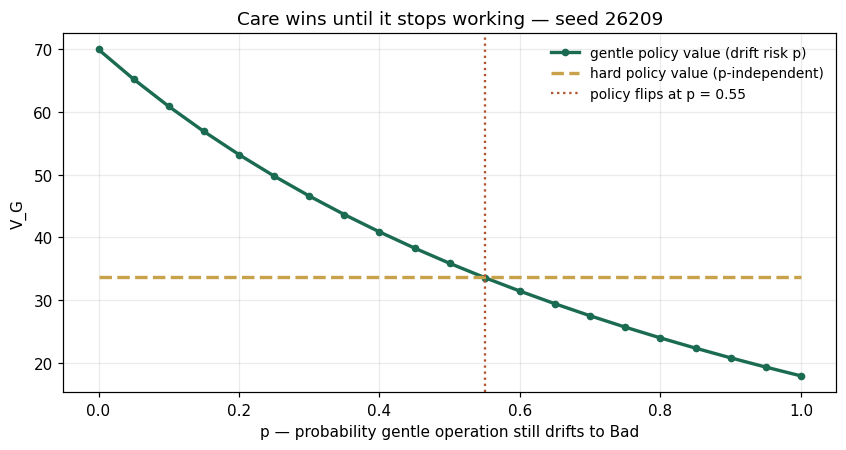

p=0.2: V=(53.2203, 43.8983), gentle optimal: True
p=0.6: hard fixed point V_G = 33.6842, hard optimal: True


In [2]:
ps = [round(0.05*i,2) for i in range(21)]
Vg = [gentle_fp(p)[0] for p in ps]
Vh = [hard_fp()[0]]*len(ps)
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ps, Vg, "o-", c="#1B6B52", lw=2.2, ms=4, label="gentle policy value (drift risk p)")
ax.plot(ps, Vh, "--", c="#C8A24B", lw=2.2, label="hard policy value (p-independent)")
ax.axvline(p_flip(), c="#B0532F", ls=":", lw=1.5, label=f"policy flips at p = {p_flip()}")
ax.set(xlabel="p — probability gentle operation still drifts to Bad", ylabel="V_G",
       title="Care wins until it stops working — seed 26209")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"p=0.2: V=({gentle_fp(0.2)[0]:.4f}, {gentle_fp(0.2)[1]:.4f}), gentle optimal: {policy_in_G(0.2)==0}")
print(f"p=0.6: hard fixed point V_G = {hard_fp()[0]:.4f}, hard optimal: {policy_in_G(0.6)==1}")

## Panel 2 — Uncertainty reprices; this policy survives
The stochastic HJB (Thm.) adds curvature: $\rho V = \max_c[\ln c +
V'(rx-c) + \tfrac{1}{2}\sigma^2 x^2 V'']$. With log utility the ansatz
$V = A_\sigma + \ln(x)/\rho$ still verifies — **residual identically zero**
— and the FOC still gives $c^* = \rho x$: the feedback law is untouched by
$\sigma$. What moves is the level: $A_\sigma$ falls by
$\sigma^2/2\rho^2 = 2.0$ exactly, so $V(10) = -5 - 2 = -7$. The sharpest
contrast with Panel 1: there uncertainty rewrote the rule; here it only
reprices the enterprise — which of the two happens is a property of the
problem, not of uncertainty itself.

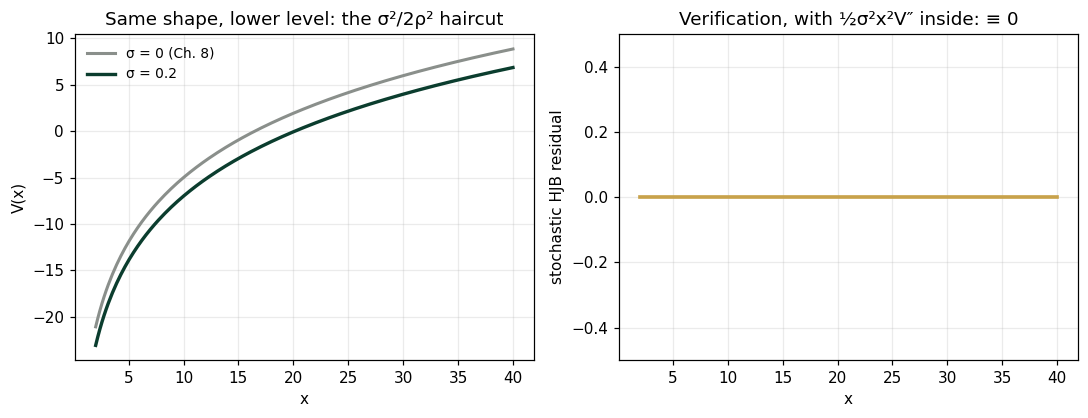

c*(10) = 1.0000 (unchanged)   V_sigma(10) = -7.0000   drop = 2.0000
residuals: x=10 -> 0.000000   x=25 -> 0.000000


In [3]:
xs = np.linspace(2, 40, 200)
fig, axes = plt.subplots(1,2, figsize=(10,3.9))
axes[0].plot(xs, [V_sig(x,0.0) for x in xs], c="#8A8F8B", lw=2, label="σ = 0 (Ch. 8)")
axes[0].plot(xs, [V_sig(x,SIG) for x in xs], c="#0B3D2E", lw=2.2, label="σ = 0.2")
axes[0].set(xlabel="x", ylabel="V(x)", title="Same shape, lower level: the σ²/2ρ² haircut")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)
axes[1].plot(xs, [resid_sig(x) for x in xs], c="#C8A24B", lw=2.4)
axes[1].set(xlabel="x", ylabel="stochastic HJB residual", ylim=(-0.5,0.5), title="Verification, with ½σ²x²V″ inside: ≡ 0")
axes[1].grid(alpha=.25)
plt.tight_layout(); plt.show()
print(f"c*(10) = {RHO*10:.4f} (unchanged)   V_sigma(10) = {V_sig(10.0):.4f}   drop = {SIG**2/(2*RHO**2):.4f}")
print(f"residuals: x=10 -> {resid_sig(10.0):.6f}   x=25 -> {resid_sig(25.0):.6f}")

## Panel 3 — Uncertainty as a purchasable guarantee
Revenue $R = m \cdot i$ with $m \sim N(2, 0.5^2)$; require
$P(R \geq 10) \geq 1-\alpha$. The Chance Constraint (Def.) has a
deterministic equivalent through the normal quantile:
$i \geq L/(\mu - z_{1-\alpha}\sigma_m)$. Deterministic plan: 5 units. The
95% guarantee: **8.49 units — a 3.49 premium**, and 99% costs 11.95. A hard
(worst-case) guarantee is impossible under unbounded noise; the chance
constraint makes the problem feasible at a price you can read off a quantile
(Chance Constraints Enlarge the Class of Feasible Problems, Prop.).

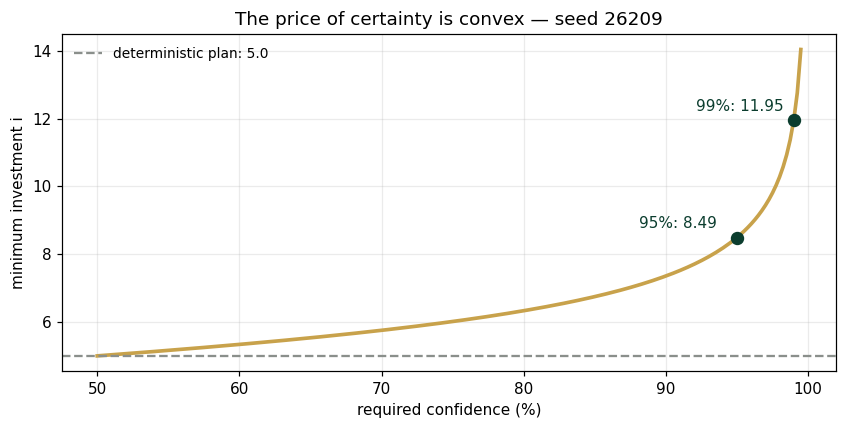

i(95%) = 8.4920   premium over deterministic: 3.4920   i(99%) = 11.9499


In [4]:
confs = np.linspace(0.50, 0.995, 200)
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.plot(confs*100, [i_min(c) for c in confs], c="#C8A24B", lw=2.4)
for c,lab in ((0.95,"95%"),(0.99,"99%")):
    ax.scatter([c*100],[i_min(c)], c="#0B3D2E", s=60, zorder=5)
    ax.annotate(f"{lab}: {i_min(c):.2f}", (c*100, i_min(c)), textcoords="offset points", xytext=(-64,6), fontsize=10, color="#0B3D2E")
ax.axhline(L/MU, c="#8A8F8B", ls="--", lw=1.5, label="deterministic plan: 5.0")
ax.set(xlabel="required confidence (%)", ylabel="minimum investment i",
       title="The price of certainty is convex — seed 26209")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"i(95%) = {i_min(0.95):.4f}   premium over deterministic: {i_min(0.95)-L/MU:.4f}   i(99%) = {i_min(0.99):.4f}")

## Validation — agrees with `DCT_V2_Ch09_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"VG_p02":53.2203,"VB_p02":43.8983,"policy_G_p02":0,"VG_hardFP":33.6842,
 "policy_G_p06":1,"p_flip":0.55,"c_star_sigma":1.0,"value_drop":2.0,"V_sigma_x10":-7.0,
 "resid_sigma_x10":0.0,"resid_sigma_x25":0.0,"i_min_95":8.492,"i_det":5.0,
 "guarantee_premium":3.492,"i_min_99":11.9499}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
print("\nAll checkpoints agree — seed 26209.")

PASS  VG_p02               53.2203
PASS  VB_p02               43.8983
PASS  policy_G_p02         0
PASS  VG_hardFP            33.6842
PASS  policy_G_p06         1
PASS  p_flip               0.55
PASS  c_star_sigma         1.0
PASS  value_drop           2.0
PASS  V_sigma_x10          -7.0
PASS  resid_sigma_x10      0.0
PASS  resid_sigma_x25      0.0
PASS  i_min_95             8.492
PASS  i_det                5.0
PASS  guarantee_premium    3.492
PASS  i_min_99             11.9499

All checkpoints agree — seed 26209.


**Next**: Exercises 9.5–9.9 (Part C) sweep β against the flip threshold and add drift risk to the Bad state; AXIOM-09's uncertainty console animates the fan of random trajectories. Chapter 10 asks what happens when even the distribution is unknown. Solutions: IM Vol. II, Ch. 9.